<a href="https://colab.research.google.com/github/Prince-kearl/ID-Card-Identification-System/blob/main/princeKeteni_NYC_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Dataset and Initial Inspection

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/AB_NYC_2019.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# Display basic information about the DataFrame, including data types and non-null values
print('\nDataFrame Info:')
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review    

In [ ]:
# Display descriptive statistics for numerical columns
print('\nDescriptive statistics:')
display(df.describe())


Descriptive statistics:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Missing Value Imputation

An initial assessment of `df.info()` reveals the presence of missing values. The subsequent step involves quantifying these missing values and defining an appropriate imputation strategy.

In [ ]:
# Check for missing values
print('\nMissing values count:')
display(df.isnull().sum())

print('\nMissing values percentage:')
display(df.isnull().sum() / len(df) * 100)


Missing values count:


,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0



Missing values percentage:


,0
id,0.000000
name,0.032723
host_id,0.000000
host_name,0.042949
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


In [ ]:
# Fill missing values in 'reviews_per_month' with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Fill missing values in 'name' and 'host_name' with 'Unknown'
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

# Fill missing values in 'last_review' with 'Missing' and convert to datetime
df['last_review'] = df['last_review'].fillna('Missing')
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')


print('\nMissing values after imputation:')
display(df.isnull().sum())


Missing values after imputation:


,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


### Data Cleaning: Outlier and Inconsistency Management

This section addresses the identification and treatment of potential outliers and data inconsistencies, with a particular focus on key numerical attributes such as `price`, `minimum_nights`, and `number_of_reviews`.

In [ ]:
# Identify and handle rows where 'price' is 0
print(f"Number of listings with price = 0: {df[df['price'] == 0].shape[0]}")
df = df[df['price'] > 0]

# Remove listings with extremely high prices (e.g., greater than $1000)
print(f"Number of listings with price > 1000: {df[df['price'] > 1000].shape[0]}")
df = df[df['price'] <= 1000]

# Remove listings with very high minimum_nights (e.g., greater than 365)
print(f"Number of listings with minimum_nights > 365: {df[df['minimum_nights'] > 365].shape[0]}")
df = df[df['minimum_nights'] <= 365]

# Verify changes
print('\nDescriptive statistics after cleaning:')
display(df.describe())

Number of listings with price = 0: 11
Number of listings with price > 1000: 239
Number of listings with minimum_nights > 365: 14

Descriptive statistics after cleaning:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.863100e+04,4.863100e+04,48631.000000,48631.000000,48631.000000,48631.000000,48631.000000,38720,48631.000000,48631.000000,48631.000000
mean,1.901839e+07,6.762227e+07,40.728938,-73.952049,141.312866,6.782937,23.360038,2018-10-04 14:00:58.760330752,1.094834,7.164216,112.391540
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.475315e+06,7.828522e+06,40.690020,-73.982980,69.000000,1.000000,1.000000,2018-07-10 00:00:00,0.040000,1.000000,0.000000
50%,1.967517e+07,3.082680e+07,40.722970,-73.955600,105.000000,3.000000,5.000000,2019-05-19 00:00:00,0.380000,1.000000,44.000000
75%,2.914624e+07,1.074344e+08,40.763130,-73.936120,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.590000,2.000000,225.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,1000.000000,365.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.097952e+07,7.860380e+07,0.054572,0.046171,116.737448,16.123039,44.636278,NaN,1.599551,33.031242,131.403672


### Exploratory Data Analysis (EDA)

Commencing the exploratory analysis, the distribution of the 'price' column will be visualized, given its significance as a primary target variable for subsequent modeling efforts.

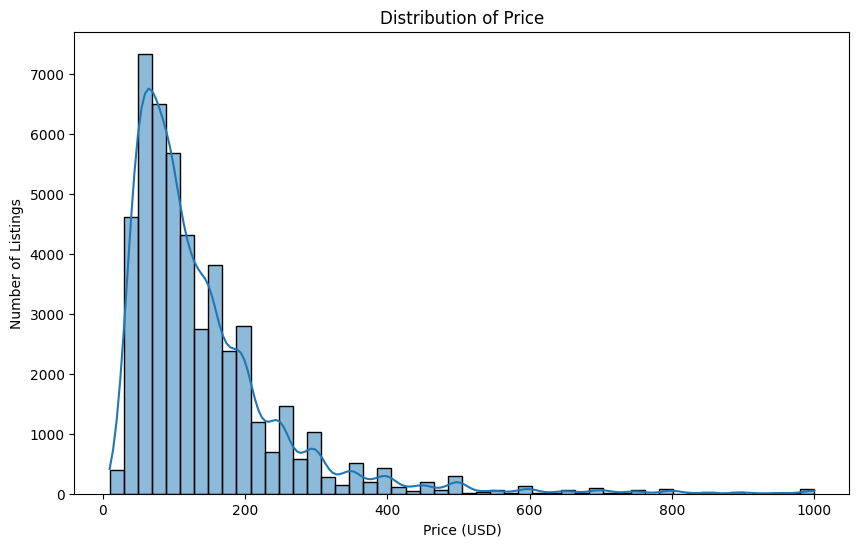

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Listings')
plt.show()

Subsequently, the distribution of listings will be examined across the various `neighbourhood_group` and `room_type` categories.

/tmp/ipykernel_967/1584449302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group', palette='viridis')


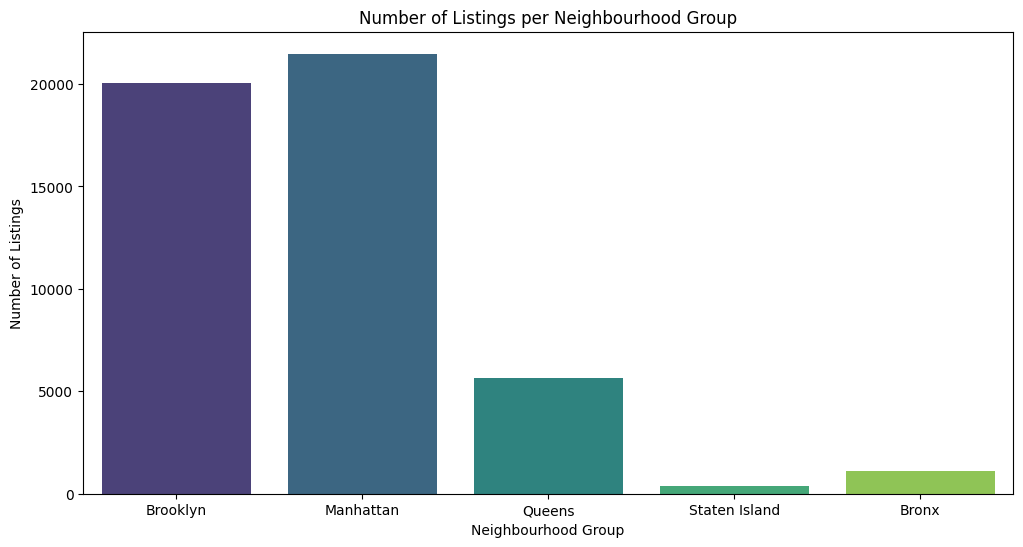

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='neighbourhood_group', palette='viridis')
plt.title('Number of Listings per Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.show()

/tmp/ipykernel_967/942989168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='room_type', palette='magma')


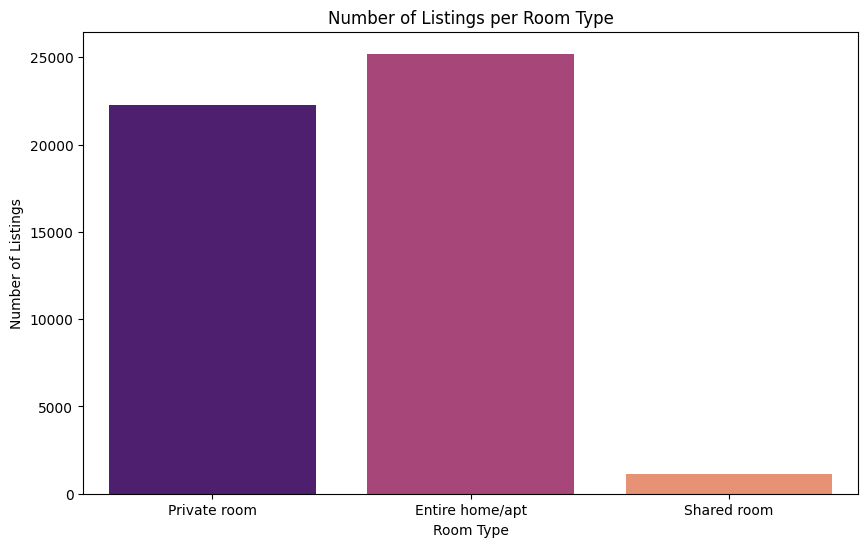

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='room_type', palette='magma')
plt.title('Number of Listings per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.show()

Furthermore, the relationship between `price` and the categorical features `neighbourhood_group` and `room_type` will be investigated.

/tmp/ipykernel_967/2754979689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='neighbourhood_group', y='price', palette='viridis')


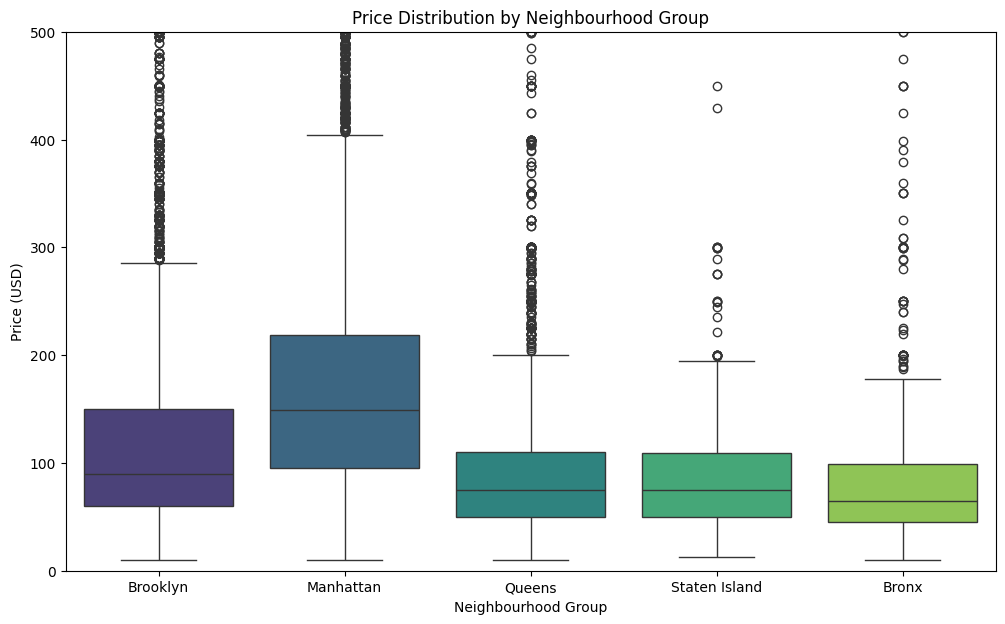

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='neighbourhood_group', y='price', palette='viridis')
plt.title('Price Distribution by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price (USD)')
plt.ylim(0, 500) # Limit y-axis for better visualization of common prices
plt.show()

/tmp/ipykernel_967/4231866819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='price', palette='magma')


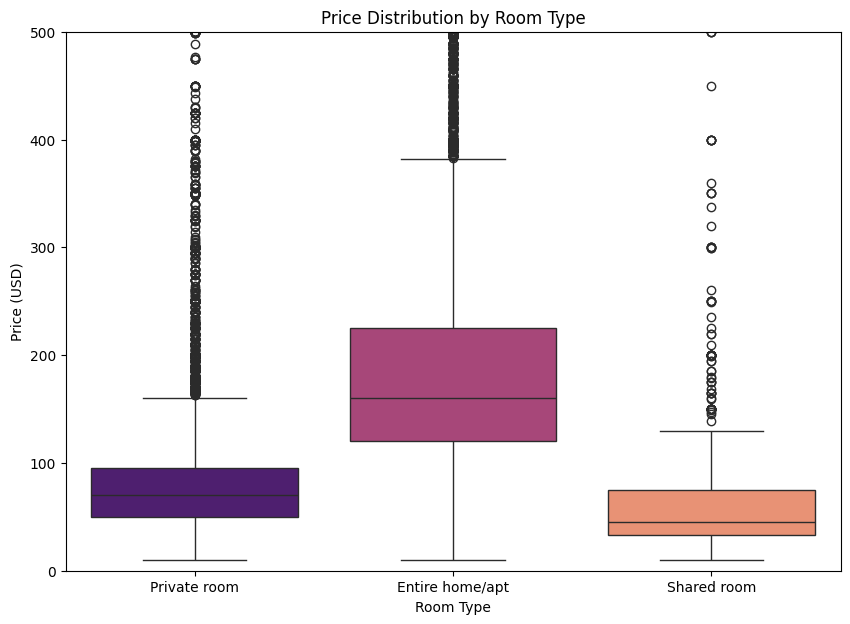

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, x='room_type', y='price', palette='magma')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')
plt.ylim(0, 500) # Limit y-axis for better visualization of common prices
plt.show()

### Feature Engineering

To prepare the data for machine learning models, categorical features will be transformed into a numerical representation using one-hot encoding for `neighbourhood_group`, `room_type`, and `neighbourhood`. The original categorical columns and other non-essential features will then be removed.

In [ ]:
# Drop irrelevant columns for modeling
df_model = df.drop(['id', 'name', 'host_name', 'last_review'], axis=1)

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, columns=['neighbourhood_group', 'room_type', 'neighbourhood'], drop_first=True)

# Display the first few rows of the preprocessed DataFrame
print('DataFrame after feature engineering:')
display(df_model.head())

# Display the shape of the new DataFrame
print(f'Shape of the DataFrame after feature engineering: {df_model.shape}')

DataFrame after feature engineering:


,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,...,neighbourhood_Westerleigh,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside
0,2787,40.64749,-73.97237,149,1,9,0.21,6,365,True,...,False,False,False,False,False,False,False,False,False,False
1,2845,40.75362,-73.98377,225,1,45,0.38,2,355,False,...,False,False,False,False,False,False,False,False,False,False
2,4632,40.80902,-73.94190,150,3,0,0.00,1,365,False,...,False,False,False,False,False,False,False,False,False,False
3,4869,40.68514,-73.95976,89,1,270,4.64,1,194,True,...,False,False,False,False,False,False,False,False,False,False
4,7192,40.79851,-73.94399,80,10,9,0.10,1,0,False,...,False,False,False,False,False,False,False,False,False,False


Shape of the DataFrame after feature engineering: (48631, 235)


### Model Building

With the data now preprocessed, the objective is to construct a predictive machine learning model. A RandomForestRegressor will be employed for this task, chosen for its robustness to diverse data types and outliers. Initially, the dataset will be partitioned into training and testing subsets.

### Feature Importance Analysis


Top 20 Feature Importances:


,Feature,Importance
12,room_type_Private room,0.192019
2,longitude,0.162944
1,latitude,0.129902
0,host_id,0.102534
7,availability_365,0.095774
5,reviews_per_month,0.055778
3,minimum_nights,0.054708
4,number_of_reviews,0.046717
6,calculated_host_listings_count,0.036938
13,room_type_Shared room,0.023673


/tmp/ipykernel_967/2421164130.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')


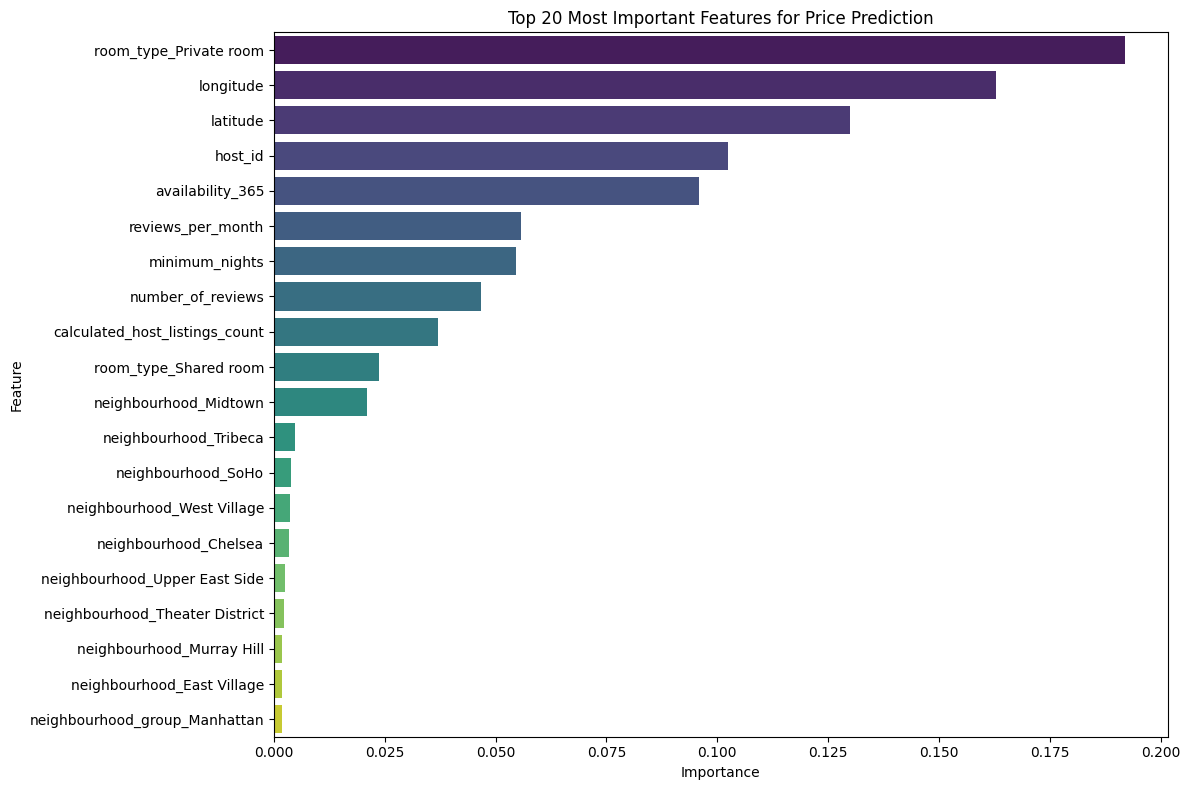

In [ ]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print('\nTop 20 Feature Importances:')
display(features_df.head(20))

# Visualize the top 20 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title('Top 20 Most Important Features for Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Tuning: Hyperparameter Optimization

To improve the model's performance, hyperparameter tuning will be performed using `GridSearchCV`. The focus will be on optimizing `n_estimators` (the number of trees in the forest) and `max_features` (the number of features to consider when looking for the best split).

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None]  # Number of features to consider for best split
}

# Initialize a new RandomForestRegressor for tuning
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid, cv=3, scoring='r2', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
print('\nStarting GridSearchCV...')
grid_search.fit(X_train, y_train)

print('\nGridSearchCV complete.')

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'\nBest parameters found: {best_params}')
print(f'Best R2 score on training data with cross-validation: {best_score:.2f}')

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f'\nModel Evaluation after Tuning:')
print(f'Mean Squared Error (MSE): {mse_tuned:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_tuned:.2f}')
print(f'R-squared (R2): {r2_tuned:.2f}')


Starting GridSearchCV...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

GridSearchCV complete.

Best parameters found: {'max_features': 'sqrt', 'n_estimators': 150}
Best R2 score on training data with cross-validation: 0.44

Model Evaluation after Tuning:
Mean Squared Error (MSE): 6584.55
Root Mean Squared Error (RMSE): 81.15
R-squared (R2): 0.48


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df_model.drop('price', axis=1)
y = df_model['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Training target shape: {y_train.shape}')
print(f'Testing target shape: {y_test.shape}')

# Initialize and train the RandomForestRegressor model
# Using a small number of estimators for faster execution in Colab, can be increased for better performance
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'\nModel Evaluation:')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Training features shape: (38904, 234)
Testing features shape: (9727, 234)
Training target shape: (38904,)
Testing target shape: (9727,)

Model Evaluation:
Mean Squared Error (MSE): 7006.52
Root Mean Squared Error (RMSE): 83.70
R-squared (R2): 0.45
